[![Text: CC BY-SA 4.0](https://img.shields.io/badge/text-CC%20BY--SA%204.0-lightgrey.svg)](https://creativecommons.org/licenses/by-sa/4.0/)
[![Code: MIT](https://img.shields.io/badge/code-MIT-yellow.svg)](https://opensource.org/license/mit)

This notebook is part of course materials for CS 545: Machine Learning at
Colorado State University. These notebooks are based on the PyTorch version of
[Dive into Deep Learning](https://d2l.ai) by Aston Zhang, Zachary C. Lipton,
Mu Li and Alexander J. Smola, used under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/) and heavily
modified by [Asa Ben-Hur](https://www.cs.colostate.edu/~asa/) with
[Claude](https://claude.com) AI. The text is released under
[CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/); the code is
released under the [MIT license](https://opensource.org/license/mit).

# Linear Regression Implementation from Scratch

We are now ready to work through 
a fully functioning implementation 
of linear regression. 
In this section, we will implement the method from scratch,
including 

1.  The model
2.  The loss function
3.  A minibatch stochastic gradient descent optimizer
4.  The training function that puts all of these pieces together.

Finally, we will use our synthetic data generator and apply our model on the resulting dataset. 
While modern deep learning frameworks  can automate nearly all of this work,
implementing things from scratch is the only way to make sure that you really know what is happening under the hood.
Moreover, when it is time to customize models, defining our own layers or loss functions, understanding how things work will prove handy.
In this section, we will rely only on tensors and automatic differentiation.
Later, we will introduce a more concise implementation,
taking advantage of the bells and whistles of PyTorch.

In [1]:
import torch
from torch import nn
from matplotlib import pyplot as plt
import numpy as np

## The Model

In the following we initialize the weights by drawing random numbers from a normal distribution with mean 0 and a standard deviation of 0.01. 
The magic number 0.01 often works well in practice, but you can specify a different value through the argument `sigma`.
Moreover we initialize the bias to 0.


In [2]:
class LinearRegressionScratch (nn.Module):
    """The linear regression model implemented from scratch."""
    def __init__(self, num_inputs, sigma=0.01):
        super().__init__()
        self.w = torch.normal(0, sigma, (num_inputs, 1), requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)

    def get_params(self):
        return self.w, self.b

    def forward(self, X):
        return torch.matmul(X, self.w) + self.b        

A couple of notes regarding the code:

* The `forward` function is the standard PyTorch method name for the function that computes the output of the model. As you recall, the output of the model is defined via the equation 
$${\hat{\mathbf{y}}} = \mathbf{X} \mathbf{w} + b.$$
The product $\mathbf{Xw}$ is a vector and $b$ is a scalar.
Because of the broadcasting mechanism 
when we add a vector and a scalar,
the scalar is added to each component of the vector.

* `get_params` is used by the optimizer to retrieve the parameters of the model.

## The Loss Function

Linear regression uses the mean squared loss function
$$L(\mathbf{w}, b) =\frac{1}{n} \sum_{i=1}^n \left(\mathbf{w}^\top \mathbf{x}^{(i)} - y^{(i)}\right)^2.$$

The following function computes the averaged loss value among all examples in a minibatch:


In [3]:
def MSEloss(y_hat, y):
    l = (y_hat - y) ** 2
    return l.mean()

## The Optimization Algorithm

As discussed, linear regression has a closed-form solution.
However, our goal here is to illustrate 
how to train more general neural networks,
and that requires that we understand minibatch SGD.
Hence we will take this opportunity
to introduce your first working example of SGD.
At each step, using a minibatch 
randomly drawn from our dataset,
we estimate the gradient of the loss
with respect to the parameters.
Next, we update the parameters
in a direction that may reduce the loss.

We define our `SGD` class to have a similar API 
as the built-in SGD optimizer.
We update the model parameters in the `step` method.
The `zero_grad` method sets all gradients to 0,
and must be run before a backpropagation step.


In [4]:
class SGD:
    """Minibatch stochastic gradient descent."""
    def __init__(self, params, lr):
        self.params = params
        self.lr = lr

    def step(self):
        # update each parameter using its gradient
        for param in self.params:
            with torch.no_grad():  # Ensure updates are not tracked in the computational graph
                param -= self.lr * param.grad

    def zero_grad(self):
        # reset gradients to zero for all parameters
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

## A synthetic dataset

We are almost ready to train the model, but first we need some training data.
We will generate a low dimensional dataset in two dimensions.
The following code snippet generates data with 2-dimensional features drawn 
from a standard normal distribution.
The resulting feature matrix $\mathbf{X}$ belongs to $\mathbb{R}^{N \times 2}$. 
We generate each label by applying a prespecified *ground truth* linear function, and corrupt each label via additive noise $\boldsymbol{\epsilon}$, drawn independently and identically for each example:

$$\mathbf{y}= \mathbf{X} \mathbf{w} + b + \boldsymbol{\epsilon}.$$

For convenience we assume that $\boldsymbol{\epsilon}$ is drawn 
from a normal distribution with mean $\mu= 0$ 
and standard deviation $\sigma = 0.01$.
Because we know the true w and b, we can later check how well training recovers them. 


In [5]:
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

# Synthetic data generator.
# We sample features from a standard normal distribution and generate 
# labels from a KNOWN linear model y = X w + b + noise. 
def synthetic_data(w, b, num_examples, noise=0.1):
    """Generate y = X w + b + noise, with w a 1D tensor of true weights."""
    X = torch.normal(0, 1, (num_examples, len(w)))
    y = torch.matmul(X, w.reshape(-1, 1)) + b
    y += torch.normal(0, noise, y.shape)
    return X, y

# Ground-truth parameters
true_w = torch.tensor([2.0, -3.4])
true_b = 4.2

torch.manual_seed(0)  # for reproducibility
X_train, y_train = synthetic_data(true_w, true_b, num_examples=1000, noise=0.1)
X_val,   y_val   = synthetic_data(true_w, true_b, num_examples=200,  noise=0.1)

print("True w:", true_w.tolist(), " True b:", true_b)
print("X_train shape:", X_train.shape, " y_train shape:", y_train.shape)

# Create TensorDataset and DataLoader for training and validation
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

batch_size = 32
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)

True w: [2.0, -3.4000000953674316]  True b: 4.2
X_train shape: torch.Size([1000, 2])  y_train shape: torch.Size([1000, 1])


In [6]:
# Inspect one minibatch
for (x, y) in train_dataloader:
    print(x.shape, y.shape)
    break

torch.Size([32, 2]) torch.Size([32, 1])


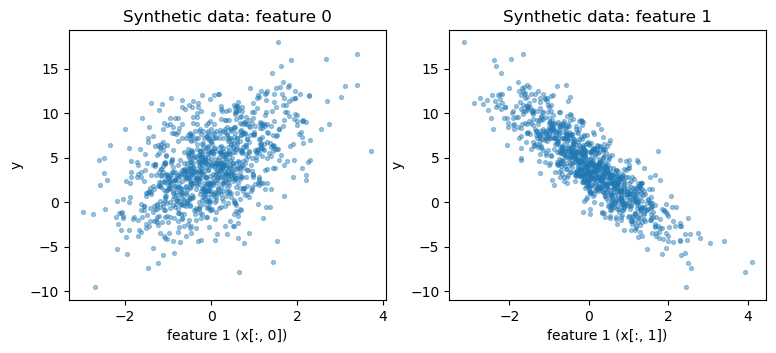

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3.5))
ax1.scatter(X_train[:, 0].numpy(), y_train.numpy(), s=8, alpha=0.4)
ax1.set_xlabel('feature 1 (x[:, 0])')
ax1.set_ylabel('y')
ax1.set_title('Synthetic data: feature 0');
ax2.scatter(X_train[:, 1].numpy(), y_train.numpy(), s=8, alpha=0.4)
ax2.set_xlabel('feature 1 (x[:, 1])')
ax2.set_ylabel('y')
ax2.set_title('Synthetic data: feature 1');

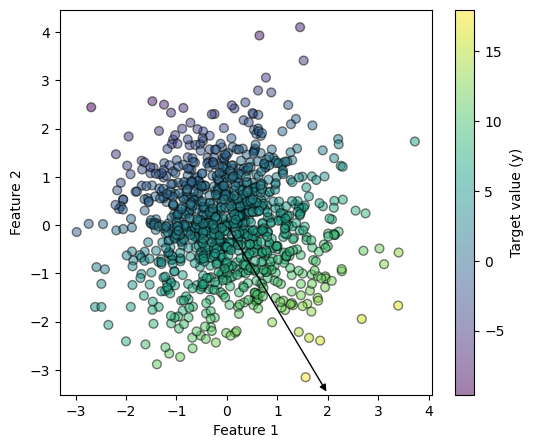

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6, 5))
plt.annotate("", xy =(0,0), xytext=(2,-3.5), arrowprops=dict(facecolor='black', arrowstyle='<|-'));
x = X_train.numpy()
scatter = plt.scatter(x[:, 0], x[:, 1], c=y_train.numpy(), cmap='viridis', s=40, edgecolor='k', alpha=0.5)
plt.colorbar(scatter, label="Target value (y)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2");

### Training the model

Now that we have all of the parts in place (parameters, loss function, model, and optimizer), we are ready to **implement the main training loop.**
It is crucial that you understand this code fully since you will employ similar training loops for every deep learning model covered in this course.
In each **epoch**, we iterate through 
the entire training dataset, 
passing once through every example
(assuming that the number of examples 
is divisible by the batch size). 
In each *iteration*, we grab a minibatch of training examples,
and compute its loss through the model's `training_step` method. 
Then we compute the gradients with respect to each parameter. 
Finally, we will call the optimization algorithm
to update the model parameters. 
In summary, we will execute the following loop:

* Initialize parameters $(\mathbf{w}, b)$
* For epoch in `max_epochs` :
    * For minibatch in data :
        * Compute gradient $\mathbf{g} \leftarrow \partial_{(\mathbf{w},b)} \frac{1}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} l(\mathbf{x}^{(i)}, y^{(i)}, \mathbf{w}, b)$
        * Update parameters $(\mathbf{w}, b) \leftarrow (\mathbf{w}, b) - \eta \mathbf{g}$
 
Note that in general, both the number of epochs 
and the learning rate are hyperparameters.
In general, setting hyperparameters is tricky
and we will usually want to use a three-way split,
one set for training, 
a second for hyperparameter selection (validation set),
and the third reserved for the final evaluation (test set).
We ignore these details for now but will revisit them later.

In [9]:
# Define the model, loss function, and optimizer
model = LinearRegressionScratch(num_inputs=2, sigma=0.01)
loss_fn = MSEloss
optimizer = SGD(params=model.get_params(), lr=0.01)

In [10]:
# training loop
epochs = 10
loss_train = []  # Track training loss
loss_valid = []  # Track validation loss

for epoch in range(epochs):
    # training phase
    model.train()
    loss_values = []  # Track batch losses during training
    
    for batch_X, batch_y in train_dataloader:
        preds = model.forward(batch_X)
        loss = loss_fn(preds, batch_y)
        loss_values.append(loss.item())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # mean training loss for the epoch
    loss_train.append(np.mean(loss_values))
    
    # validation phase
    model.eval()
    loss_values = []  # Track batch losses during validation
    
    for batch_X, batch_y in val_dataloader:
        # disable gradient calculations during validation
        with torch.no_grad():
            preds = model.forward(batch_X)
            loss = loss_fn(preds, batch_y)
            loss_values.append(loss.item())
    
    # mean validation loss for the epoch
    loss_valid.append(np.mean(loss_values))
    
    print(f"Epoch {epoch + 1}: Training Loss = {loss_train[-1]:.4f}, Validation Loss = {loss_valid[-1]:.4f}")

Epoch 1: Training Loss = 18.7378, Validation Loss = 10.0327
Epoch 2: Training Loss = 5.4322, Validation Loss = 2.7469
Epoch 3: Training Loss = 1.4706, Validation Loss = 0.7757
Epoch 4: Training Loss = 0.4114, Validation Loss = 0.2284
Epoch 5: Training Loss = 0.1200, Validation Loss = 0.0749
Epoch 6: Training Loss = 0.0410, Validation Loss = 0.0294
Epoch 7: Training Loss = 0.0179, Validation Loss = 0.0162
Epoch 8: Training Loss = 0.0118, Validation Loss = 0.0118
Epoch 9: Training Loss = 0.0099, Validation Loss = 0.0104
Epoch 10: Training Loss = 0.0094, Validation Loss = 0.0098


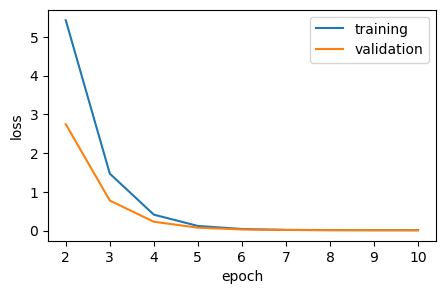

In [11]:
from matplotlib import pyplot as plt
plt.figure(figsize=(5,3))
plt.plot(range(2, len(loss_train)+1), loss_train[1:], label='training')
plt.plot(range(2, len(loss_valid)+1), loss_valid[1:], label='validation')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend();

In [12]:
# Because we generated the data ourselves, we can check how well training
# recovered the true parameters. With light noise these should be close.
w_est, b_est = model.get_params()
print("Estimated w:", w_est.detach().reshape(-1).tolist())
print("True      w:", true_w.tolist())
print("Estimated b:", b_est.detach().item())
print("True      b:", true_b)

Estimated w: [1.9957371950149536, -3.393109083175659]
True      w: [2.0, -3.4000000953674316]
Estimated b: 4.189581871032715
True      b: 4.2


## Linear regression on real data

In this part we will explore linear regression using the [diabetes dataset](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html), which is distributed with scikit-learn. It contains 442 patients, each described by 10 baseline features (age, sex, BMI, blood pressure, and six blood-serum measurements). The target is a quantitative measure of disease progression one year after baseline. The dataset is small and ships with the library, so there is no download step.

In [13]:
from sklearn.datasets import load_diabetes
import numpy as np
from matplotlib import pyplot as plt

data = load_diabetes()
X = data.data
y = data.target

In [14]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

A complete description of the dataset and its features is contained in the `DESCR` attribute of the dataset:

```python
print(data.DESCR)
```

Let's plot a histogram of the labels:

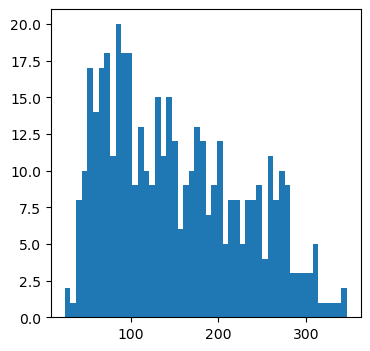

In [15]:
plt.figure(figsize=(4,4))
plt.hist(y, bins=50);

In [16]:
X, y = data.data, data.target

In [17]:
np.mean(X, axis=0)

array([-1.44429466e-18,  2.54321451e-18, -2.25592546e-16, -4.85408596e-17,
       -1.42859580e-17,  3.89881064e-17, -6.02836031e-18, -1.78809958e-17,
        9.24348582e-17,  1.35176953e-17])

In [18]:
np.std(X[:,1])

np.float64(0.047565149415449454)

In [19]:
np.sum(X[0]*X[0])

np.float64(0.014069322534936554)

In [20]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Load diabetes dataset
data = load_diabetes()

# Features (X) and target (y)
X, y = data.data, data.target

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (mean = 0, std = 1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1) # Add dimension for single target
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

# Create TensorDataset and DataLoader
batch_size = 64
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)

In [21]:
model = LinearRegressionScratch(num_inputs=X_train.shape[1], sigma=0.01)
loss_fn = MSEloss
optimizer = SGD(params=model.get_params(), lr=0.01)

In [22]:
epochs = 20

# Lists to track loss values
loss_train = [] 
loss_valid = []

for epoch in range(epochs):
    # training phase
    model.train()
    loss_values = []  # batch losses during training
    
    for batch_X, batch_y in train_dataloader:
        preds = model.forward(batch_X)
        loss = loss_fn(preds, batch_y)
        loss_values.append(loss.item())
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    # mean training loss for the epoch
    loss_train.append(np.mean(loss_values))
    
    # validation phase
    model.eval()
    loss_values = []  # Track batch losses during validation
    
    for batch_X, batch_y in val_dataloader:
        # Disable gradient calculations during validation
        with torch.no_grad():
            preds = model.forward(batch_X)
            loss = loss_fn(preds, batch_y)
            loss_values.append(loss.item())
    
    # mean validation loss for the epoch
    loss_valid.append(np.mean(loss_values))
    
    print(f"Epoch {epoch + 1}: Training Loss = {loss_train[-1]:.4f}, Validation Loss = {loss_valid[-1]:.4f}")

Epoch 1: Training Loss = 26794.5951, Validation Loss = 21537.5771
Epoch 2: Training Loss = 20905.1006, Validation Loss = 17669.9072
Epoch 3: Training Loss = 17184.3407, Validation Loss = 14582.3965
Epoch 4: Training Loss = 13882.3975, Validation Loss = 12194.7627
Epoch 5: Training Loss = 11539.3053, Validation Loss = 10280.9258
Epoch 6: Training Loss = 9512.6401, Validation Loss = 8781.9673
Epoch 7: Training Loss = 8112.4325, Validation Loss = 7576.3044
Epoch 8: Training Loss = 7329.0448, Validation Loss = 6604.3694
Epoch 9: Training Loss = 6045.5709, Validation Loss = 5844.1150
Epoch 10: Training Loss = 5540.4227, Validation Loss = 5230.6746
Epoch 11: Training Loss = 4851.3262, Validation Loss = 4726.1860
Epoch 12: Training Loss = 4407.4618, Validation Loss = 4350.3325
Epoch 13: Training Loss = 4094.8607, Validation Loss = 4035.9958
Epoch 14: Training Loss = 3899.8639, Validation Loss = 3798.4479
Epoch 15: Training Loss = 3637.0946, Validation Loss = 3583.0166
Epoch 16: Training Loss 

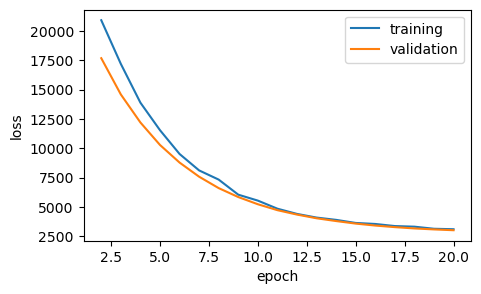

In [23]:
from matplotlib import pyplot as plt
plt.figure(figsize=(5,3))
plt.plot(range(2, len(loss_train)+1), loss_train[1:], label='training')
plt.plot(range(2, len(loss_valid)+1), loss_valid[1:], label='validation')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend();

In [24]:
loss_valid[-1]

np.float64(3017.9154052734375)

In [25]:
model.w

tensor([[  2.1389],
        [-10.1740],
        [ 24.4675],
        [ 15.3482],
        [ -3.5296],
        [ -5.7600],
        [-10.4068],
        [  6.9053],
        [ 17.9241],
        [  5.3722]], requires_grad=True)

Let's compare this to what you get using the implementation in scikit-learn:

In [26]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features (mean = 0, std = 1)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [27]:
from sklearn.linear_model import LinearRegression
linreg = LinearRegression()
linreg.fit(X_train, y_train)
np.mean( (linreg.predict(X_val) - y_val)**2)

np.float64(2900.193628493482)

It looks like the implementation in scikit-learn works a bit better.  Let's train the PyTorch model with more iterations (e.g. 30) instead of 20 and see how that changes things.

In [28]:
print("PyTorch weight vector:")
model.w

PyTorch weight vector:


tensor([[  2.1389],
        [-10.1740],
        [ 24.4675],
        [ 15.3482],
        [ -3.5296],
        [ -5.7600],
        [-10.4068],
        [  6.9053],
        [ 17.9241],
        [  5.3722]], requires_grad=True)

In [29]:
print("scikit-learn weight vector")
linreg.coef_

scikit-learn weight vector


array([  1.75375799, -11.51180908,  25.60712144,  16.82887167,
       -44.44885564,  24.64095356,   7.67697768,  13.1387839 ,
        35.16119521,   2.35136365])

In [30]:
print("The bias:")
linreg.intercept_

The bias:


np.float64(153.73654390934846)

In [31]:
model.b

tensor([140.1569], requires_grad=True)

### Comparison to an even simpler baseline

Let's check if linear regression offers an advantage over an even simpler model that predicts the output according to the mean label in the training set:

In [32]:
# the mean model
test_MSE = np.mean( (np.mean(y_val) - y_val)**2)
train_MSE = np.mean( (np.mean(y_train) - y_train)**2)

print(f"Mean model MSE (test): {test_MSE}")
print(f"Mean model MSE (train): {train_MSE}")

Mean model MSE (test): 5298.151748516601
Mean model MSE (train): 6076.398012984615


This shows that linear regression indeed provides a good improvement over the simplest possible model.  We will try to improve on this using nonlinear models.


## Summary

In this notebook, we took a significant step 
towards designing deep learning systems 
by implementing a fully functional 
neural network model and training loop.
In this process, we built a data loader, 
a model, a loss function, an optimization procedure,
and a visualization and monitoring tool. 
We did this by composing a Python object 
that contains all relevant components for training a model. 
While this is not yet a professional-grade implementation
it is perfectly functional and code like this 
could already help you to solve small problems quickly.
In the coming sections, we will see how to do this
both *more concisely* (avoiding boilerplate code)
and *more efficiently* (using our GPUs to their full potential).



## Exercises

1. What would happen if we were to initialize the weights to zero. Would the algorithm still work? What if we initialized the parameters with variance $1000$ rather than $0.01$?
1. Experiment using different learning rates to find out how quickly the loss function value drops. Can you reduce the error by increasing the number of epochs of training?
1. Why do we need to shuffle a dataset? Can you design a case where a maliciously constructed dataset would break the optimization algorithm otherwise?
